In [14]:
from datetime import datetime
from datetime import date, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np 

In [15]:
# Download data

import pandas as pd
url='https://helioforecast.space/static/sync/icmecat/HELIO4CAST_ICMECAT_v23.csv'
ic=pd.read_csv(url)
ic.keys()

ic = ic.truncate(before=0, after=1901)
# ic.icme_start_time
# print(ic.sc_insitu)

# ic = ic.loc[ic['sc_insitu'] == "Wind"] # Sort to be just Wind data
# print(ic.icme_start_time)
# print(ic.sc_insitu.unique)


In [16]:
# df_merged = pd.concat([ic.icme_start_time, ic.mo_end_time], ignore_index=True, sort=False) # Wouldn't include days inbetween start and end
# print(df_merged)
# print(df_merged.unique)


In [17]:
#######################################################################################################
### Important Note: This code doesn't really count the number of days that we want so don't use it. ###
#######################################################################################################

# Count number of wind vs non-wind data points
# DayRange = []
# Wind = 0
# NotWind = 0
# for i in range(len(ic.icme_start_time)):                            # Go through all the events
#     if ic.sc_insitu[i] == "Wind":                                   # if the observing s/c is Wind
#         Wind = Wind + 1                                             # add one to the wind counter
#         if ic.icme_start_time[i][0:10] == ic.mo_end_time[i][0:10]:  # if the event starts and ends on the same day
#             DayRange.append("Same day")                             # Note that in DayRange
#         else:                                                       # if the event doesn't start and end on the same day
#             Diff = datetime.fromisoformat(ic.mo_end_time[i]) - datetime.fromisoformat(ic.icme_start_time[i])    # Find the difference in the times
#             # print(ic.icme_start_time[i][0:10], ic.mo_end_time[i][0:10])
#             # print(Diff)
#             # print(Diff.days)
#             DayRange.append("Multi-day , over " + str(Diff.days+2)[0:6] + " day(s)")     #IMPORTANT NOTE: this doesn't account for times just over the midnight and full days well      # Add the number of days that the event spans to DayRange
#     else:                                                           # if the observing s/c isn't Wind
#         NotWind = NotWind + 1                                       # add to the NotWind counter and do nothing else
# print(DayRange)
# print(Wind)
# print(NotWind)

# UniqueDayCounts = {i:DayRange.count(i) for i in DayRange} # Count number of ICMEs in each date range
# print("UniqueDayCounts: " + str(UniqueDayCounts))

# # Number of days to remove
# UniqueDayCounts: {'Multi-day , over 3 day(s)': 248, 'Multi-day , over 2 day(s)': 147, 'Same day': 96, 'Multi-day , over 4 day(s)': 43, 'Multi-day , over 5 day(s)': 6}
# # 'Same day': 96 # number of ICMEs that start and end on the same day
# # 'Multi-day , over 2 day(s)': 147 # number of ICMEs that start and end on different days but last under 24 hours
# # 'Multi-day , over 3 day(s)': 248 # number if ICMES that last over 2 dates (and longer than 24 hours)
# # 'Multi-day , over 4 day(s)': 43 # number if ICMES that last over 3 dates 
# # 'Multi-day , over 5 day(s)': 6 # number if ICMES that last over 4 dates 

# # Total number of days to remove (assuming no overlaps)
# Total = 468 + (577*2) + (638*3) + (152*4) + (41*5) + (17*6) + (6*7) + (1*8) + (2*9)
# Total = 96 + (147*2) + (248*3) + (43*4) + (6*5)
# print(Total) # Total number of days to remove

# # Total number of days in the years
# # NOTE: The catalogue only goes to 2025-06-22 but my yearly histograms use data up to partway though 2026
# NoOfDays = (2025-1996)*365
# print(NoOfDays)
# # Removing each day that a CME occurs at ANY SPACECRAFT would make me lose half my data.
# # Removing each day that a CME occurs at Wind would make me lose half my data.

# print(Total/NoOfDays)

In [19]:
WindOnly = ic.loc[ic['sc_insitu'] == "Wind"]   # create a wind only dataframe
WindOnly.insert(0, "Index", range(0, len(WindOnly.icme_start_time)))   # set the indexes to be 0,1,2,3, etc. instead of the original event indexes
WindOnly.set_index("Index", inplace = True)
# print(WindOnly)

In [20]:
###########################################################################################
### Important Note: This code counts the number of days that we want so use it instead. ###
###########################################################################################


# Create list of dates to remove
ListOfDates = []
for i in range(len(WindOnly.icme_start_time)):
    dates = pd.date_range(datetime.fromisoformat(WindOnly.icme_start_time[i]), datetime.fromisoformat(WindOnly.mo_end_time[i]), freq='D', normalize = True) #+timedelta(days=1)
    # if len(dates) == 3: # Code for checking to see if the dates are being correctly listed
    #     print("Start: " + str(WindOnly.icme_start_time[i][0:10]) + ", End: " + str(WindOnly.mo_end_time[i][0:10]))
    #     print("Days between: " + str(dates))
    # print(dates)
    for j in range(len(dates)):
        ListOfDates.append(dates[j])

# REMOVE DUPLICATES
# print(len(ListOfDates))
ListOfDates = sorted(list(set(ListOfDates))) # Sorted, removed duplicates
# print(len(ListOfDates)) # Removed 66 dates

# WORK OUT PERCENTAGE OF DATA TO BE REMOVED
NoOfDays = (2026-1996)*365.25 # 30 years (From Jan 1996 to Dec 2025) - The catalogue only goes to August 2025(2025-08-10) so there may be some CMEs between August and December 2025
# print(NoOfDays)

print("Percentage of dates removed: ~" + str(round((len(ListOfDates)/NoOfDays) * 100, 2)) + "%")

Percentage of dates removed: ~9.86%


# Monthly

In [21]:
def ReadDates(startDate, endDate): # Get monthly dates
    DateRange = pd.date_range(startDate, endDate, freq='MS').strftime("%Y%m%d").tolist()
    return DateRange

Months = ReadDates("1996-01-01 00:00", "2025-12-31 00:00")
print(Months)
MonthCounts=np.zeros(len(Months))

for l in range(len(Months)):                                # for each month
    for j in range(len(ListOfDates)):                       # for the List of Dates
        DateCheck = ListOfDates[j].strftime('%Y-%m-%d')     # get the date from the Lists
        DateCheck = DateCheck.replace("-", "")              # format it the same as the months so you can compare them
        # print(DateCheck[0:6])                             
        if DateCheck[0:6] == Months[l][0:6]:                # if the date from ListOfDates exists in the month you are checking
            # print(Months[l][0:6])
            MonthCounts[l] = MonthCounts[l] + 1             # then add one to the count for that month

print(MonthCounts)

['19960101', '19960201', '19960301', '19960401', '19960501', '19960601', '19960701', '19960801', '19960901', '19961001', '19961101', '19961201', '19970101', '19970201', '19970301', '19970401', '19970501', '19970601', '19970701', '19970801', '19970901', '19971001', '19971101', '19971201', '19980101', '19980201', '19980301', '19980401', '19980501', '19980601', '19980701', '19980801', '19980901', '19981001', '19981101', '19981201', '19990101', '19990201', '19990301', '19990401', '19990501', '19990601', '19990701', '19990801', '19990901', '19991001', '19991101', '19991201', '20000101', '20000201', '20000301', '20000401', '20000501', '20000601', '20000701', '20000801', '20000901', '20001001', '20001101', '20001201', '20010101', '20010201', '20010301', '20010401', '20010501', '20010601', '20010701', '20010801', '20010901', '20011001', '20011101', '20011201', '20020101', '20020201', '20020301', '20020401', '20020501', '20020601', '20020701', '20020801', '20020901', '20021001', '20021101', '20

# Three monthly

In [22]:
def ReadDates3Month(startDate, endDate): # Get monthly dates
    DateRange = pd.date_range(startDate, endDate, freq='3MS').strftime("%Y%m%d").tolist()
    return DateRange

ThreeMonths = ReadDates3Month("1996-01-01 00:00", "2025-12-31 00:00")
print(ThreeMonths)

# print("First batch")
# print(ThreeMonths[0][0:6])
# print(str(int(ThreeMonths[0][0:6]) + 1))
# print(str(int(ThreeMonths[0][0:6]) + 2))
# print("Second batch")
# print(ThreeMonths[1][0:6])
# print(str(int(ThreeMonths[1][0:6]) + 1))
# print(str(int(ThreeMonths[1][0:6]) + 2))

ThreeMonthCounts=np.zeros(len(ThreeMonths))

for l in range(len(ThreeMonths)):                           # for each 3 month section
    for j in range(len(ListOfDates)):                       # for the List of Dates
        DateCheck = ListOfDates[j].strftime('%Y-%m-%d')     # get the date from the Lists
        DateCheck = DateCheck.replace("-", "")              # format it the same as the months so you can compare them
        # print(DateCheck[0:6])                             
        if DateCheck[0:6] == ThreeMonths[l][0:6] or DateCheck[0:6] == str(int(ThreeMonths[l][0:6]) + 1) or DateCheck[0:6] == str(int(ThreeMonths[l][0:6]) + 2):   # if the date from ListOfDates exists in the month you are checking
            # print(Months[l][0:6])
            ThreeMonthCounts[l] = ThreeMonthCounts[l] + 1             # then add one to the count for that month

print(ThreeMonthCounts)

['19960101', '19960401', '19960701', '19961001', '19970101', '19970401', '19970701', '19971001', '19980101', '19980401', '19980701', '19981001', '19990101', '19990401', '19990701', '19991001', '20000101', '20000401', '20000701', '20001001', '20010101', '20010401', '20010701', '20011001', '20020101', '20020401', '20020701', '20021001', '20030101', '20030401', '20030701', '20031001', '20040101', '20040401', '20040701', '20041001', '20050101', '20050401', '20050701', '20051001', '20060101', '20060401', '20060701', '20061001', '20070101', '20070401', '20070701', '20071001', '20080101', '20080401', '20080701', '20081001', '20090101', '20090401', '20090701', '20091001', '20100101', '20100401', '20100701', '20101001', '20110101', '20110401', '20110701', '20111001', '20120101', '20120401', '20120701', '20121001', '20130101', '20130401', '20130701', '20131001', '20140101', '20140401', '20140701', '20141001', '20150101', '20150401', '20150701', '20151001', '20160101', '20160401', '20160701', '20

# Yearly

In [23]:
# Years = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", 
#          "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", 
#          "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"] # All the years we want included
# YearCounts=np.zeros(len(Years)) # make an empty array for filling with the number of events in each year

def ReadDatesYear(startDate, endDate): # Get monthly dates
    DateRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return DateRange

Year = ReadDatesYear("1996-01-01 00:00", "2025-12-31 00:00")
print(Year)

# print("First batch")
# print(ThreeMonths[0][0:6])
# print(str(int(ThreeMonths[0][0:6]) + 1))
# print(str(int(ThreeMonths[0][0:6]) + 2))
# print("Second batch")
# print(ThreeMonths[1][0:6])
# print(str(int(ThreeMonths[1][0:6]) + 1))
# print(str(int(ThreeMonths[1][0:6]) + 2))

YearCounts=np.zeros(len(Year))

for l in range(len(Year)):                           # for each year
    for j in range(len(ListOfDates)):                       # for the List of Dates
        DateCheck = ListOfDates[j].strftime('%Y-%m-%d')     # get the date from the Lists
        DateCheck = DateCheck.replace("-", "")              # format it the same as the years so you can compare them
        # print(DateCheck[0:6])                             
        if DateCheck[0:4] == Year[l][0:4]:   # if the date from ListOfDates exists in the month you are checking
            # print(Months[l][0:6])
            YearCounts[l] = YearCounts[l] + 1             # then add one to the count for that month

print(YearCounts)

['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101']
[14. 43. 62. 34. 69. 54. 43. 23. 28. 34. 26. 13.  8. 27. 31. 43. 74. 48.
 36. 34. 20. 18. 14. 14. 21. 56. 41. 55. 72. 25.]


# Solar Wind Code

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00, 47.81file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  2.82file/s]
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/home/rahyndman/miniforge3/envs/sunpyVenv/lib/python3.14/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function

['19960101', '19970101', '19980101', '19990101', '20000101', '20010101', '20020101', '20030101', '20040101', '20050101', '20060101', '20070101', '20080101', '20090101', '20100101', '20110101', '20120101', '20130101', '20140101', '20150101', '20160101', '20170101', '20180101', '20190101', '20200101', '20210101', '20220101', '20230101', '20240101', '20250101', '20260101']
[['1996-01-01', '1996-12-31'], ['1997-01-01', '1997-12-31'], ['1998-01-01', '1998-12-31'], ['1999-01-01', '1999-12-31'], ['2000-01-01', '2000-12-31'], ['2001-01-01', '2001-12-31'], ['2002-01-01', '2002-12-31'], ['2003-01-01', '2003-12-31'], ['2004-01-01', '2004-12-31'], ['2005-01-01', '2005-12-31'], ['2006-01-01', '2006-12-31'], ['2007-01-01', '2007-12-31'], ['2008-01-01', '2008-12-31'], ['2009-01-01', '2009-12-31'], ['2010-01-01', '2010-12-31'], ['2011-01-01', '2011-12-31'], ['2012-01-01', '2012-12-31'], ['2013-01-01', '2013-12-31'], ['2014-01-01', '2014-12-31'], ['2015-01-01', '2015-12-31'], ['2016-01-01', '2016-12-31

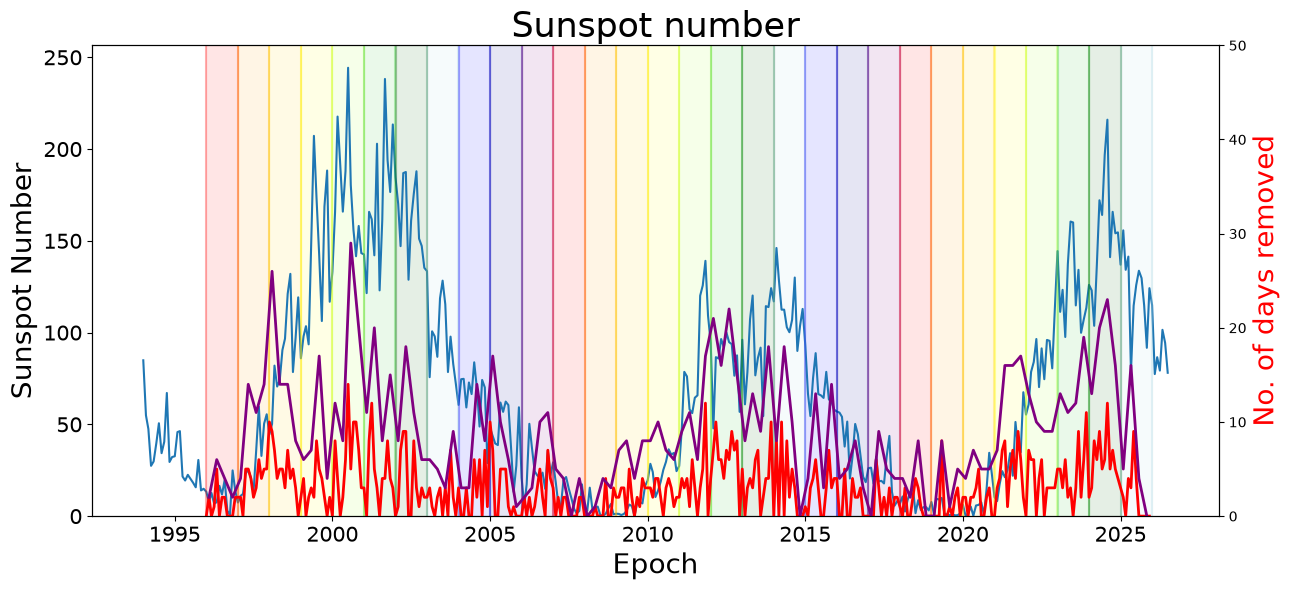

In [24]:
########################
### Solar cycle code ###
########################

#Imports
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.time import Time, TimeDelta
from astropy.visualization import time_support

import sunpy.timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a
from sunpy.time import TimeRange

import numpy as np
import pandas as pd

# get data
time_range = TimeRange("1994-01-01 00:00", Time.now()) # I've used the start of the year before the C23 minimum that Tindale and Chapman (2017) use
result = Fido.search(a.Time(time_range), a.Instrument('noaa-indices')) # fido search for the noaa indices in the time range
f_noaa_indices = Fido.fetch(result)
result = Fido.search(a.Time(time_range.end, time_range.end + TimeDelta(4 * u.year)),
                     a.Instrument('noaa-predict')) # get the predicted sunspot numbers from NOAA (4 years in future)
f_noaa_predict = Fido.fetch(result)

#loading data into TimeSeries objects
noaa = ts.TimeSeries(f_noaa_indices, source='noaaindices').truncate(time_range) 
noaa_predict = ts.TimeSeries(f_noaa_predict, source='noaapredictindices')

TitleSize = 25
AxisSize = 20
TickSize = 15

Start  = "1996-01-01 00:00" # from SIDC
End  = "2026-12-31 23:59" 

def Yearly(startDate, endDate): #ReadDatesForFileFinding
    YearlyRange = pd.date_range(startDate, endDate, freq='YS').strftime("%Y%m%d").tolist()
    return YearlyRange

YearlyRange = Yearly(Start, End)
print(YearlyRange)

StartAndEnd = []
for i in range(len(YearlyRange)-1):
    StartDate = YearlyRange[i]
    EndDate = YearlyRange[i][0:4] + "1231"
    # print(StartDate, EndDate)
    StartAndEnd.append([StartDate[0:4] + "-" + StartDate[4:6] + "-" + StartDate[6:8], EndDate[0:4] + "-" + EndDate[4:6] + "-" + EndDate[6:8]])

print(StartAndEnd)

time_support()
# fig, ax = plt.subplots(figsize=(13,6))
fig, ax1 = plt.subplots(figsize=(13,6))
ax1.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')

import datetime as date
times = [date.datetime(1995,1,1), date.datetime(2000,1,1), date.datetime(2005,1,1), date.datetime(2010,1,1), date.datetime(2015,1,1), date.datetime(2020,1,1), date.datetime(2025,1,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
ax1.set_xticks(t,t_yr)

ax1.set_ylim(bottom=0)
ax1.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax1.set_xlabel('Epoch', fontsize=AxisSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

dateRanges = []
for i in range(len(StartAndEnd)):
    dateRanges.append([Time(StartAndEnd[i][0]).jd1-2400000, Time(StartAndEnd[i][1]).jd1-2400000])

Colours = ["red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple"]

for i in range(len(dateRanges)):
    # # print(len(dateRanges))
    # ax1.axvline(dateRanges[i][0], color=Colours[i], alpha = 0.5)
    # # ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0] + "->" + StartAndEnd[i][1])
    # ax1.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0][0:4])
    # ax1.axvline(dateRanges[i][1], color=Colours[i], alpha = 0.5)

    # Dimmer
    # print(len(dateRanges))
    ax1.axvline(dateRanges[i][0], color=Colours[i], alpha = 0.3)
    # ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0] + "->" + StartAndEnd[i][1])
    ax1.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.1, label = StartAndEnd[i][0][0:4])
    ax1.axvline(dateRanges[i][1], color=Colours[i], alpha = 0.3)

###############################
### End of Solar cycle code ###
###############################

# Code for ICMECat part of plot
##OLD VERSION

# OldYears = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", 
#          "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", 
#          "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]
# OldYearCounts=np.zeros(len(OldYears))

# for l in range(len(OldYears)):
#     for j in WindOnly.icme_start_time:
#         if j[0:4] == OldYears[l]:
#             OldYearCounts[l] = OldYearCounts[l] + 1

# print(OldYearCounts)

# timesICME = [date.datetime(1995,6,1), date.datetime(2000,6,1), date.datetime(2005,6,1), date.datetime(2010,6,1), date.datetime(2015,6,1), date.datetime(2020,6,1), date.datetime(2025,6,1)]
# t_yr = [tm.year for tm in timesICME]
# t=Time(timesICME, format='datetime')
# # fig, axs = plt.subplots(1,1, figsize=(15,5))
# subset = [YearCounts[0], YearCounts[5], YearCounts[10], YearCounts[15], YearCounts[20], YearCounts[25], YearCounts[26]]

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

# times = [date.datetime(1996,6,1), date.datetime(1997,6,1), date.datetime(1998,6,1), date.datetime(1999,6,1), date.datetime(2000,6,1), date.datetime(2001,6,1), date.datetime(2002,6,1), date.datetime(2003,6,1), date.datetime(2004,6,1), date.datetime(2005,6,1), date.datetime(2006,6,1), date.datetime(2007,6,1), date.datetime(2008,6,1), date.datetime(2009,6,1), date.datetime(2010,6,1), date.datetime(2011,6,1), date.datetime(2012,6,1), date.datetime(2013,6,1), date.datetime(2014,6,1), date.datetime(2015,6,1), date.datetime(2016,6,1), date.datetime(2017,6,1), date.datetime(2018,6,1), date.datetime(2019,6,1), date.datetime(2020,6,1), date.datetime(2021,6,1), date.datetime(2022,6,1), date.datetime(2023,6,1), date.datetime(2024,6,1), date.datetime(2025,6,1)]
# t_yr = [tm.year for tm in times]
# t=Time(times, format='datetime')
# ax.set_xticks(t,t_yr)

#Months
# start_date = '1996-01-01'
# end_date = '2025-12-31'
# timesMonths = pd.Series([pd.to_datetime(start_date)] + [i for i in pd.date_range(start=start_date, end=end_date) if i.day == 1] + [pd.to_datetime(end_date)]).drop_duplicates()
# # # timesMonths.to_frame()
# # pd.to_datetime(timesMonths)
# print(timesMonths)
# # t_months = [tm.month for tm in timesMonths]
# # tMonths=Time(timesMonths, format='datetime')


# timesMonths = pd.date_range(start="1996-01-01",end="2026-12-31")
timesMonths = [date.datetime(1996,1,1), date.datetime(1996,2,1), date.datetime(1996,3,1), date.datetime(1996,4,1), date.datetime(1996,5,1), date.datetime(1996,6,1), date.datetime(1996,7,1), date.datetime(1996,8,1), date.datetime(1996,9,1), date.datetime(1996,10,1), date.datetime(1996,11,1), date.datetime(1996,12,1), 
               date.datetime(1997,1,1), date.datetime(1997,2,1), date.datetime(1997,3,1), date.datetime(1997,4,1), date.datetime(1997,5,1), date.datetime(1997,6,1), date.datetime(1997,7,1), date.datetime(1997,8,1), date.datetime(1997,9,1), date.datetime(1997,10,1), date.datetime(1997,11,1), date.datetime(1997,12,1), 
               date.datetime(1998,1,1), date.datetime(1998,2,1), date.datetime(1998,3,1), date.datetime(1998,4,1), date.datetime(1998,5,1), date.datetime(1998,6,1), date.datetime(1998,7,1), date.datetime(1998,8,1), date.datetime(1998,9,1), date.datetime(1998,10,1), date.datetime(1998,11,1), date.datetime(1998,12,1), 
               date.datetime(1999,1,1), date.datetime(1999,2,1), date.datetime(1999,3,1), date.datetime(1999,4,1), date.datetime(1999,5,1), date.datetime(1999,6,1), date.datetime(1999,7,1), date.datetime(1999,8,1), date.datetime(1999,9,1), date.datetime(1999,10,1), date.datetime(1999,11,1), date.datetime(1999,12,1), 
               date.datetime(2000,1,1), date.datetime(2000,2,1), date.datetime(2000,3,1), date.datetime(2000,4,1), date.datetime(2000,5,1), date.datetime(2000,6,1), date.datetime(2000,7,1), date.datetime(2000,8,1), date.datetime(2000,9,1), date.datetime(2000,10,1), date.datetime(2000,11,1), date.datetime(2000,12,1), 
               date.datetime(2001,1,1), date.datetime(2001,2,1), date.datetime(2001,3,1), date.datetime(2001,4,1), date.datetime(2001,5,1), date.datetime(2001,6,1), date.datetime(2001,7,1), date.datetime(2001,8,1), date.datetime(2001,9,1), date.datetime(2001,10,1), date.datetime(2001,11,1), date.datetime(2001,12,1), 
               date.datetime(2002,1,1), date.datetime(2002,2,1), date.datetime(2002,3,1), date.datetime(2002,4,1), date.datetime(2002,5,1), date.datetime(2002,6,1), date.datetime(2002,7,1), date.datetime(2002,8,1), date.datetime(2002,9,1), date.datetime(2002,10,1), date.datetime(2002,11,1), date.datetime(2002,12,1), 
               date.datetime(2003,1,1), date.datetime(2003,2,1), date.datetime(2003,3,1), date.datetime(2003,4,1), date.datetime(2003,5,1), date.datetime(2003,6,1), date.datetime(2003,7,1), date.datetime(2003,8,1), date.datetime(2003,9,1), date.datetime(2003,10,1), date.datetime(2003,11,1), date.datetime(2003,12,1), 
               date.datetime(2004,1,1), date.datetime(2004,2,1), date.datetime(2004,3,1), date.datetime(2004,4,1), date.datetime(2004,5,1), date.datetime(2004,6,1), date.datetime(2004,7,1), date.datetime(2004,8,1), date.datetime(2004,9,1), date.datetime(2004,10,1), date.datetime(2004,11,1), date.datetime(2004,12,1), 
               date.datetime(2005,1,1), date.datetime(2005,2,1), date.datetime(2005,3,1), date.datetime(2005,4,1), date.datetime(2005,5,1), date.datetime(2005,6,1), date.datetime(2005,7,1), date.datetime(2005,8,1), date.datetime(2005,9,1), date.datetime(2005,10,1), date.datetime(2005,11,1), date.datetime(2005,12,1), 
               date.datetime(2006,1,1), date.datetime(2006,2,1), date.datetime(2006,3,1), date.datetime(2006,4,1), date.datetime(2006,5,1), date.datetime(2006,6,1), date.datetime(2006,7,1), date.datetime(2006,8,1), date.datetime(2006,9,1), date.datetime(2006,10,1), date.datetime(2006,11,1), date.datetime(2006,12,1), 
               date.datetime(2007,1,1), date.datetime(2007,2,1), date.datetime(2007,3,1), date.datetime(2007,4,1), date.datetime(2007,5,1), date.datetime(2007,6,1), date.datetime(2007,7,1), date.datetime(2007,8,1), date.datetime(2007,9,1), date.datetime(2007,10,1), date.datetime(2007,11,1), date.datetime(2007,12,1), 
               date.datetime(2008,1,1), date.datetime(2008,2,1), date.datetime(2008,3,1), date.datetime(2008,4,1), date.datetime(2008,5,1), date.datetime(2008,6,1), date.datetime(2008,7,1), date.datetime(2008,8,1), date.datetime(2008,9,1), date.datetime(2008,10,1), date.datetime(2008,11,1), date.datetime(2008,12,1), 
               date.datetime(2009,1,1), date.datetime(2009,2,1), date.datetime(2009,3,1), date.datetime(2009,4,1), date.datetime(2009,5,1), date.datetime(2009,6,1), date.datetime(2009,7,1), date.datetime(2009,8,1), date.datetime(2009,9,1), date.datetime(2009,10,1), date.datetime(2009,11,1), date.datetime(2009,12,1), 
               date.datetime(2010,1,1), date.datetime(2010,2,1), date.datetime(2010,3,1), date.datetime(2010,4,1), date.datetime(2010,5,1), date.datetime(2010,6,1), date.datetime(2010,7,1), date.datetime(2010,8,1), date.datetime(2010,9,1), date.datetime(2010,10,1), date.datetime(2010,11,1), date.datetime(2010,12,1), 
               date.datetime(2011,1,1), date.datetime(2011,2,1), date.datetime(2011,3,1), date.datetime(2011,4,1), date.datetime(2011,5,1), date.datetime(2011,6,1), date.datetime(2011,7,1), date.datetime(2011,8,1), date.datetime(2011,9,1), date.datetime(2011,10,1), date.datetime(2011,11,1), date.datetime(2011,12,1), 
               date.datetime(2012,1,1), date.datetime(2012,2,1), date.datetime(2012,3,1), date.datetime(2012,4,1), date.datetime(2012,5,1), date.datetime(2012,6,1), date.datetime(2012,7,1), date.datetime(2012,8,1), date.datetime(2012,9,1), date.datetime(2012,10,1), date.datetime(2012,11,1), date.datetime(2012,12,1), 
               date.datetime(2013,1,1), date.datetime(2013,2,1), date.datetime(2013,3,1), date.datetime(2013,4,1), date.datetime(2013,5,1), date.datetime(2013,6,1), date.datetime(2013,7,1), date.datetime(2013,8,1), date.datetime(2013,9,1), date.datetime(2013,10,1), date.datetime(2013,11,1), date.datetime(2013,12,1), 
               date.datetime(2014,1,1), date.datetime(2014,2,1), date.datetime(2014,3,1), date.datetime(2014,4,1), date.datetime(2014,5,1), date.datetime(2014,6,1), date.datetime(2014,7,1), date.datetime(2014,8,1), date.datetime(2014,9,1), date.datetime(2014,10,1), date.datetime(2014,11,1), date.datetime(2014,12,1), 
               date.datetime(2015,1,1), date.datetime(2015,2,1), date.datetime(2015,3,1), date.datetime(2015,4,1), date.datetime(2015,5,1), date.datetime(2015,6,1), date.datetime(2015,7,1), date.datetime(2015,8,1), date.datetime(2015,9,1), date.datetime(2015,10,1), date.datetime(2015,11,1), date.datetime(2015,12,1), 
               date.datetime(2016,1,1), date.datetime(2016,2,1), date.datetime(2016,3,1), date.datetime(2016,4,1), date.datetime(2016,5,1), date.datetime(2016,6,1), date.datetime(2016,7,1), date.datetime(2016,8,1), date.datetime(2016,9,1), date.datetime(2016,10,1), date.datetime(2016,11,1), date.datetime(2016,12,1), 
               date.datetime(2017,1,1), date.datetime(2017,2,1), date.datetime(2017,3,1), date.datetime(2017,4,1), date.datetime(2017,5,1), date.datetime(2017,6,1), date.datetime(2017,7,1), date.datetime(2017,8,1), date.datetime(2017,9,1), date.datetime(2017,10,1), date.datetime(2017,11,1), date.datetime(2017,12,1), 
               date.datetime(2018,1,1), date.datetime(2018,2,1), date.datetime(2018,3,1), date.datetime(2018,4,1), date.datetime(2018,5,1), date.datetime(2018,6,1), date.datetime(2018,7,1), date.datetime(2018,8,1), date.datetime(2018,9,1), date.datetime(2018,10,1), date.datetime(2018,11,1), date.datetime(2018,12,1), 
               date.datetime(2019,1,1), date.datetime(2019,2,1), date.datetime(2019,3,1), date.datetime(2019,4,1), date.datetime(2019,5,1), date.datetime(2019,6,1), date.datetime(2019,7,1), date.datetime(2019,8,1), date.datetime(2019,9,1), date.datetime(2019,10,1), date.datetime(2019,11,1), date.datetime(2019,12,1), 
               date.datetime(2020,1,1), date.datetime(2020,2,1), date.datetime(2020,3,1), date.datetime(2020,4,1), date.datetime(2020,5,1), date.datetime(2020,6,1), date.datetime(2020,7,1), date.datetime(2020,8,1), date.datetime(2020,9,1), date.datetime(2020,10,1), date.datetime(2020,11,1), date.datetime(2020,12,1), 
               date.datetime(2021,1,1), date.datetime(2021,2,1), date.datetime(2021,3,1), date.datetime(2021,4,1), date.datetime(2021,5,1), date.datetime(2021,6,1), date.datetime(2021,7,1), date.datetime(2021,8,1), date.datetime(2021,9,1), date.datetime(2021,10,1), date.datetime(2021,11,1), date.datetime(2021,12,1),  
               date.datetime(2022,1,1), date.datetime(2022,2,1), date.datetime(2022,3,1), date.datetime(2022,4,1), date.datetime(2022,5,1), date.datetime(2022,6,1), date.datetime(2022,7,1), date.datetime(2022,8,1), date.datetime(2022,9,1), date.datetime(2022,10,1), date.datetime(2022,11,1), date.datetime(2022,12,1), 
               date.datetime(2023,1,1), date.datetime(2023,2,1), date.datetime(2023,3,1), date.datetime(2023,4,1), date.datetime(2023,5,1), date.datetime(2023,6,1), date.datetime(2023,7,1), date.datetime(2023,8,1), date.datetime(2023,9,1), date.datetime(2023,10,1), date.datetime(2023,11,1), date.datetime(2023,12,1),  
               date.datetime(2024,1,1), date.datetime(2024,2,1), date.datetime(2024,3,1), date.datetime(2024,4,1), date.datetime(2024,5,1), date.datetime(2024,6,1), date.datetime(2024,7,1), date.datetime(2024,8,1), date.datetime(2024,9,1), date.datetime(2024,10,1), date.datetime(2024,11,1), date.datetime(2024,12,1), 
               date.datetime(2025,1,1), date.datetime(2025,2,1), date.datetime(2025,3,1), date.datetime(2025,4,1), date.datetime(2025,5,1), date.datetime(2025,6,1), date.datetime(2025,7,1), date.datetime(2025,8,1), date.datetime(2025,9,1), date.datetime(2025,10,1), date.datetime(2025,11,1), date.datetime(2025,12,1)]
t_months = [tm.month for tm in timesMonths]
tMonths=Time(timesMonths, format='datetime')
# ax.set_xticks(t,t_yr)


# print(len(tMonths))
# t3Months = []
# for g in range(int(len(tMonths)/3)):
#     h = (g*3) + 1
#     t3Months.append(tMonths[h])
# print(t3Months)

# timesMonths = pd.date_range(start="1996-01-01",end="2026-12-31")
times3Months = [date.datetime(1996,2,1), date.datetime(1996,5,1), date.datetime(1996,8,1), date.datetime(1996,11,1), 
                date.datetime(1997,2,1), date.datetime(1997,5,1), date.datetime(1997,8,1), date.datetime(1997,11,1),
                date.datetime(1998,2,1), date.datetime(1998,5,1), date.datetime(1998,8,1), date.datetime(1998,11,1),
               date.datetime(1999,2,1), date.datetime(1999,5,1), date.datetime(1999,8,1), date.datetime(1999,11,1), 
               date.datetime(2000,2,1), date.datetime(2000,5,1), date.datetime(2000,8,1), date.datetime(2000,11,1), 
               date.datetime(2001,2,1), date.datetime(2001,5,1), date.datetime(2001,8,1), date.datetime(2001,11,1), 
               date.datetime(2002,2,1), date.datetime(2002,5,1), date.datetime(2002,8,1), date.datetime(2002,11,1), 
               date.datetime(2003,2,1), date.datetime(2003,5,1), date.datetime(2003,8,1), date.datetime(2003,11,1), 
               date.datetime(2004,2,1), date.datetime(2004,5,1), date.datetime(2004,8,1), date.datetime(2004,11,1), 
               date.datetime(2005,2,1), date.datetime(2005,5,1), date.datetime(2005,8,1), date.datetime(2005,11,1), 
               date.datetime(2006,2,1), date.datetime(2006,5,1), date.datetime(2006,8,1), date.datetime(2006,11,1), 
               date.datetime(2007,2,1), date.datetime(2007,5,1), date.datetime(2007,8,1), date.datetime(2007,11,1), 
               date.datetime(2008,2,1), date.datetime(2008,5,1), date.datetime(2008,8,1), date.datetime(2008,11,1), 
               date.datetime(2009,2,1), date.datetime(2009,5,1), date.datetime(2009,8,1), date.datetime(2009,11,1), 
               date.datetime(2010,2,1), date.datetime(2010,5,1), date.datetime(2010,8,1), date.datetime(2010,11,1), 
               date.datetime(2011,2,1), date.datetime(2011,5,1), date.datetime(2011,8,1), date.datetime(2011,11,1), 
               date.datetime(2012,2,1), date.datetime(2012,5,1), date.datetime(2012,8,1), date.datetime(2012,11,1), 
               date.datetime(2013,2,1), date.datetime(2013,5,1), date.datetime(2013,8,1), date.datetime(2013,11,1), 
               date.datetime(2014,2,1), date.datetime(2014,5,1), date.datetime(2014,8,1), date.datetime(2014,11,1), 
               date.datetime(2015,2,1), date.datetime(2015,5,1), date.datetime(2015,8,1), date.datetime(2015,11,1), 
               date.datetime(2016,2,1), date.datetime(2016,5,1), date.datetime(2016,8,1), date.datetime(2016,11,1), 
               date.datetime(2017,2,1), date.datetime(2017,5,1), date.datetime(2017,8,1), date.datetime(2017,11,1), 
               date.datetime(2018,2,1), date.datetime(2018,5,1), date.datetime(2018,8,1), date.datetime(2018,11,1), 
               date.datetime(2019,2,1), date.datetime(2019,5,1), date.datetime(2019,8,1), date.datetime(2019,11,1), 
               date.datetime(2020,2,1), date.datetime(2020,5,1), date.datetime(2020,8,1), date.datetime(2020,11,1), 
               date.datetime(2021,2,1), date.datetime(2021,5,1), date.datetime(2021,8,1), date.datetime(2021,11,1), 
               date.datetime(2022,2,1), date.datetime(2022,5,1), date.datetime(2022,8,1), date.datetime(2022,11,1), 
               date.datetime(2023,2,1), date.datetime(2023,5,1), date.datetime(2023,8,1), date.datetime(2023,11,1),  
               date.datetime(2024,2,1), date.datetime(2024,5,1), date.datetime(2024,8,1), date.datetime(2024,11,1), 
               date.datetime(2025,2,1), date.datetime(2025,5,1), date.datetime(2025,8,1), date.datetime(2025,11,1)]
t_3months = [tm.month for tm in times3Months]
t3Months=Time(times3Months, format='datetime')
print(t3Months)
# ax.set_xticks(t,t_yr)

# ThreeMonthCounts = []
# for a in range(int(len(MonthCounts)/3)):
#     threeMonthCount = MonthCounts[3*a] + MonthCounts[3*a+1] + MonthCounts[3*a+2]
#     ThreeMonthCounts.append(threeMonthCount)
# print(ThreeMonthCounts)

ax2.plot(tMonths, MonthCounts, color = "red", linewidth=2) # Months
ax2.plot(t3Months, ThreeMonthCounts, color = "purple", linewidth=2) # 3 months
# ax2.plot(tMonths, MonthCounts, color = "red", linewidth=3) # Months
# ax2.plot(t3Months, ThreeMonthCounts, color = "purple", linewidth=3) # 3 months
# ax2.plot(t, YearCounts, color = "blue", linewidth=3) # Fixed
# ax2.plot(t, OldYearCounts, color = "red", linewidth=3) # Old
ax2.set_ylabel('No. of days removed', color="red", fontsize=AxisSize)  # we already handled the x-label with ax1

ax2.set_ylim(0, 50) 

# fig.legend(loc="outside right", fontsize=8)
fig.tight_layout()  # otherwise the right y-label is slightly clipped

# plt.savefig("YearlySunspotNumber.png")
plt.show()

# Years

[ 8. 21. 30. 16. 31. 23. 20. 10. 13. 16. 13.  7.  5. 15. 15. 22. 30. 21.
 15. 14.  9. 10.  8.  6. 10. 31. 23. 32. 49. 17.]


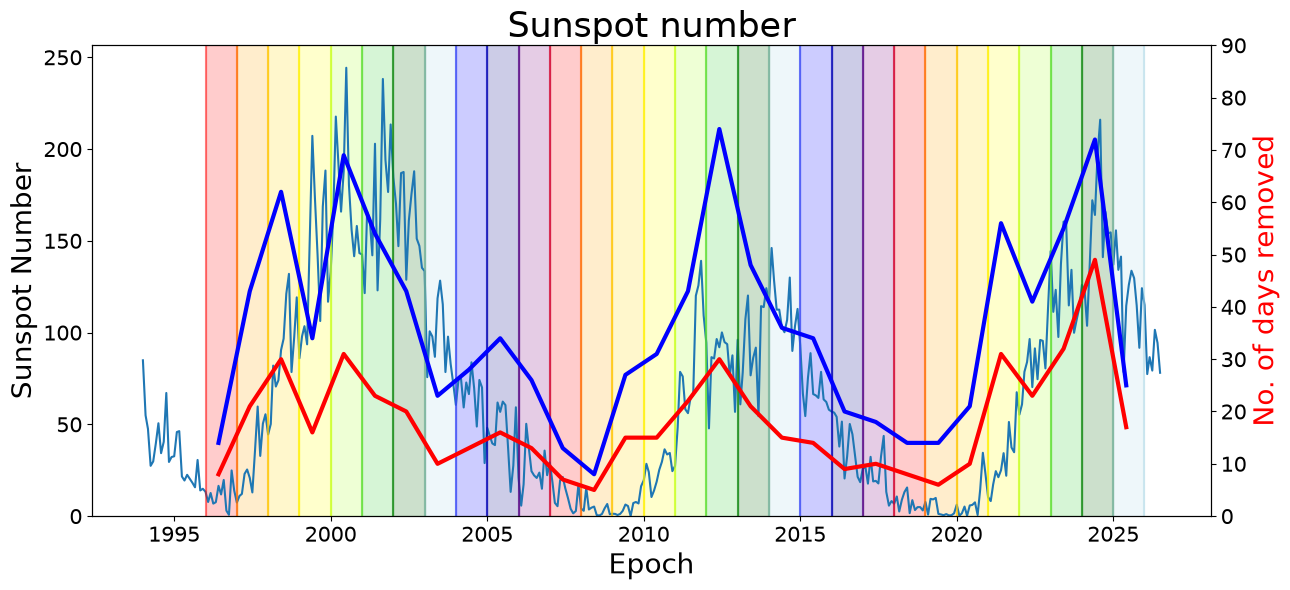

In [26]:
########################
### Solar cycle code ###
########################

fig, ax1 = plt.subplots(figsize=(13,6))
ax1.plot(noaa.time, noaa.quantity('sunspot RI'), label='Sunspot Number')

import datetime as date
times = [date.datetime(1995,1,1), date.datetime(2000,1,1), date.datetime(2005,1,1), date.datetime(2010,1,1), date.datetime(2015,1,1), date.datetime(2020,1,1), date.datetime(2025,1,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
ax1.set_xticks(t,t_yr)

ax1.set_ylim(bottom=0)
ax1.set_ylabel('Sunspot Number', fontsize=AxisSize)
ax1.set_xlabel('Epoch', fontsize=AxisSize)

plt.xticks(fontsize=TickSize)
plt.yticks(fontsize=TickSize)
plt.title("Sunspot number", fontsize=TitleSize)

dateRanges = []
for i in range(len(StartAndEnd)):
    dateRanges.append([Time(StartAndEnd[i][0]).jd1-2400000, Time(StartAndEnd[i][1]).jd1-2400000])

Colours = ["red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple", "red", "orange", "gold", "yellow", "greenyellow", "limegreen", "darkgreen", "lightblue", "blue", "darkblue", "purple"]

for i in range(len(dateRanges)):
    # print(len(dateRanges))
    ax1.axvline(dateRanges[i][0], color=Colours[i], alpha = 0.5)
    # ax.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0] + "->" + StartAndEnd[i][1])
    ax1.axvspan(dateRanges[i][0], dateRanges[i][1], color=Colours[i], alpha=0.2, label = StartAndEnd[i][0][0:4])
    ax1.axvline(dateRanges[i][1], color=Colours[i], alpha = 0.5)

###############################
### End of solar cycle code ###
###############################

# Code for ICMECat part of plot
##OLD VERSION

OldYears = ["1996", "1997", "1998", "1999", "2000", "2001", "2002", "2003", "2004", "2005", "2006", 
         "2007", "2008", "2009", "2010", "2011", "2012", "2013", "2014", "2015", "2016", "2017", 
         "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025"]
OldYearCounts=np.zeros(len(OldYears))

for l in range(len(OldYears)):
    for j in WindOnly.icme_start_time:
        if j[0:4] == OldYears[l]:
            OldYearCounts[l] = OldYearCounts[l] + 1

print(OldYearCounts)

# timesICME = [date.datetime(1995,6,1), date.datetime(2000,6,1), date.datetime(2005,6,1), date.datetime(2010,6,1), date.datetime(2015,6,1), date.datetime(2020,6,1), date.datetime(2025,6,1)]
# t_yr = [tm.year for tm in timesICME]
# t=Time(timesICME, format='datetime')
# # fig, axs = plt.subplots(1,1, figsize=(15,5))
# subset = [YearCounts[0], YearCounts[5], YearCounts[10], YearCounts[15], YearCounts[20], YearCounts[25], YearCounts[26]]

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

times = [date.datetime(1996,6,1), date.datetime(1997,6,1), date.datetime(1998,6,1), date.datetime(1999,6,1), date.datetime(2000,6,1), date.datetime(2001,6,1), date.datetime(2002,6,1), date.datetime(2003,6,1), date.datetime(2004,6,1), date.datetime(2005,6,1), date.datetime(2006,6,1), date.datetime(2007,6,1), date.datetime(2008,6,1), date.datetime(2009,6,1), date.datetime(2010,6,1), date.datetime(2011,6,1), date.datetime(2012,6,1), date.datetime(2013,6,1), date.datetime(2014,6,1), date.datetime(2015,6,1), date.datetime(2016,6,1), date.datetime(2017,6,1), date.datetime(2018,6,1), date.datetime(2019,6,1), date.datetime(2020,6,1), date.datetime(2021,6,1), date.datetime(2022,6,1), date.datetime(2023,6,1), date.datetime(2024,6,1), date.datetime(2025,6,1)]
t_yr = [tm.year for tm in times]
t=Time(times, format='datetime')
# ax.set_xticks(t,t_yr)

ax2.plot(t, YearCounts, color = "blue", linewidth=3) # Fixed
ax2.plot(t, OldYearCounts, color = "red", linewidth=3) # Old
ax2.set_ylabel('No. of days removed', color="red", fontsize=AxisSize)  # we already handled the x-label with ax1
plt.yticks(fontsize=TickSize)

ax2.set_ylim(0, 90)
# ax2.set_ylim(0, 200) 


# fig.legend(loc="outside right", fontsize=8)
fig.tight_layout()  # otherwise the right y-label is slightly clipped

# plt.savefig("YearlySunspotNumber.png")
plt.show()

Search catalogue for CME times for specific spacecraft?

Decide how to remove the times (start/end of MO? ICME start time + ICME duration? MO duration?

How do they define MO and compare it to CME defn?

Sometimes one without the other

# Solar Phase code from Daragh - Not finished

In [27]:
import datetime as dt
from pathlib import Path
from typing import List, Sequence, overload

import numpy as np
import polars as pl
import requests
import scipy.signal

type TimeOrTimes = dt.datetime | Sequence[dt.datetime]



@overload
def get_solar_cycle_phase(t: dt.datetime) -> float: ...
@overload
def get_solar_cycle_phase(t: Sequence[dt.datetime]) -> List[float]: ...


def get_solar_cycle_phase(
    t: TimeOrTimes, cache_dir= Path("/home/rahyndman/SolarWindCode/Data")
) -> float | List[float]:

    # cache_dir.mkdir(parents=True, exist_ok=True)

    if isinstance(t, List):
        input_is_vector = True
        input_times = t

    elif isinstance(t, dt.datetime):
        input_is_vector = False
        # For ease of writing, we consider the single value input as a list of length 1.
        input_times = [t]

    else:
        raise ValueError(
            "Invalid input to `get_solar_cycle_phase`, must be time or list of times"
        )

    # Convert to decimal year
    decimal_years = [datetime_to_decimal_year(t) for t in input_times]

    # Fetch sunspot numbers
    sunspot_numbers = (
        get_sunspot_numbers(cache_dir=cache_dir)
        .select("Decimal Year", "Mean")
        .filter(pl.col("Decimal Year") > 1960)
    )

    # Peaks should be ~11 years apart. A minmum peak distance of 6 years
    # visually works well.
    maxima_indices, _ = scipy.signal.find_peaks(
        sunspot_numbers["Mean"], distance=6 * 12
    )
    minima_indices, _ = scipy.signal.find_peaks(
        -sunspot_numbers["Mean"], distance=6 * 12
    )
    maxima = sunspot_numbers["Decimal Year"][maxima_indices]
    minima = sunspot_numbers["Decimal Year"][minima_indices]

    # Combine maxima and minima and sort
    reference_times = np.concatenate([maxima, minima])
    labels = np.concatenate([np.zeros(len(maxima)), np.full(len(minima), np.pi)])

    sort_order = np.argsort(reference_times)
    reference_times = reference_times[sort_order]
    labels = labels[sort_order]

    offset = labels[0]  # 0 if first is a maximum, π if first is a minimum
    known_phases = np.arange(len(labels)) * np.pi + offset

    # Find phase at time
    ouput_phases = [
        t % (2 * np.pi)
        for t in np.interp(
            decimal_years,
            reference_times,
            known_phases,
        ).ravel()
    ]

    # _, ax = plt.subplots()
    # ax.plot(sunspot_numbers["Decimal Year"], sunspot_numbers["Mean"])
    # for m in maxima:
    #     ax.axvline(m, color="red")
    #
    # for m in minima:
    #     ax.axvline(m, color="green")
    #
    # ax.plot(decimal_years, ouput_phases)
    #
    # plt.show()

    return ouput_phases if input_is_vector else ouput_phases[0]


def get_sunspot_numbers(
    cache_dir= Path("/home/rahyndman/SolarWindCode/Data"),
) -> pl.DataFrame:
    """Fetches a timeseries of sunspot number"""

    # 13 month smoothed total sunspot number
    url = "https://www.sidc.be/SILSO/INFO/snmstotcsv.php"
    path = cache_dir / "monthly_sunspot_number.csv"

    # Ensure cache_dir exists
    # cache_dir.mkdir(exist_ok=True)

    # Check if the file exists before downloading:
    if not path.exists():
        response = requests.get(url)
        with open(path, "wb") as file:
            file.write(response.content)

    data = pl.read_csv(
        path,
        new_columns=[
            "Year",
            "Month",
            "Decimal Year",
            "Mean",
            "Standard Deviation",
            "N Observations",
            "Provisional Marker",
        ],
        schema_overrides={
            "Mean": pl.Float64,
            "Standard Deviation": pl.Float64,
            "N Observations": pl.Float64,
        },
        has_header=False,
        separator=";",
    )

    return data


def datetime_to_decimal_year(d: dt.datetime) -> float:
    year_start = dt.datetime(d.year, 1, 1)
    year_end = dt.datetime(d.year + 1, 1, 1)
    year_length = (year_end - year_start).total_seconds()

    elapsed = (d - year_start).total_seconds()

    return d.year + elapsed / year_length


In [28]:
get_solar_cycle_phase(date.datetime(1996,1,1))

np.float64(2.9612858279567504)